# Deepfake Detection

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement or use deepfake detection methods
- Evaluate detection performance and limitations

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1, lesson 05 (the GAN) and Course 04 (AIAT 114) — Unit 3: detection is a classifier trained on the output of a generator you already know how to build.

**Used later in:** Course 10 — Unit 4, lesson 04, where detection and provenance become regulatory obligations.

---

## 🌍 Why this lesson exists — Arup, Hong Kong, February 2024

A finance employee at the engineering firm **Arup** joined a video conference with the company's chief financial officer and several colleagues. Every other participant on the call was a deepfake. Over a single day he authorised **15 transfers totalling HK$200 million (about US$25.6 million)**. Hong Kong police disclosed the case in February 2024; Arup publicly confirmed it was the victim in May 2024. As of early 2025 none of the funds had been recovered.

The control that failed is one almost every business process still relies on: *I can see and hear who I am talking to.*

**What goes wrong without this:** identity verification has rested for a century on face and voice. A generator that clears that bar breaks a control thousands of processes depend on, all at once — and automated detection is the only defence that can run at scale after the fact.


# Deepfake Detection
## AIAT 124 - Generative AI

## Learning Objectives

- Understand deepfake generation
- Implement deepfake detection
- Use CNN for detection
- Apply to security and verification

## Real-World Context

Security, verification, and content authenticity.

**Industry Impact**: Critical for preventing misinformation and fraud.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: install and import PyTorch + torchvision.
# We need torch to build/train the GAN (fake maker) and the CNN detector (fake catcher),
# and torchvision for the MNIST dataset that plays the role of "real" images.
%pip install torch torchvision -q
import torch
import torch.nn as nn
print('✅ Setup complete!')

Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Part 1: Deepfake Detection Model

A deepfake detector is just a **binary image classifier**: input an image, output *real* or *fake*.
Below we define a small CNN detector for 28×28 grayscale images — later in this notebook we will
actually **train it and measure how well it detects** GAN-generated fakes.

In [2]:
# Define the deepfake detector: a small CNN that classifies an image as real or fake.
# Why a CNN? Generation artifacts (blur, checkerboard patterns, odd textures) are local
# pixel patterns — exactly what convolutional filters are good at picking up.
class DeepfakeDetector(nn.Module):
    """CNN-based real-vs-fake image classifier for 1x28x28 images."""
    def __init__(self):
        super().__init__()
        # Feature extractor: two conv blocks, each halving the spatial size (28 -> 14 -> 7)
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),   # 1 gray channel -> 16 feature maps
            nn.ReLU(), nn.MaxPool2d(2),        # downsample 28x28 -> 14x14
            nn.Conv2d(16, 32, 3, padding=1),  # 16 -> 32 feature maps
            nn.ReLU(), nn.MaxPool2d(2),        # downsample 14x14 -> 7x7
        )
        # Classifier head: flatten the feature maps and decide real (0) vs fake (1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(), nn.Dropout(0.3),        # dropout fights overfitting on our small set
            nn.Linear(64, 2)                   # 2 logits: [real, fake]
        )

    def forward(self, x):
        return self.classifier(self.features(x))

print('✅ Deepfake detector architecture defined')

✅ Deepfake detector architecture defined


## Part 2: Detection Techniques


In [3]:
# WHAT/WHY: name the four families of deepfake-detection methods before the
# hands-on artifact-based detector below.
print('📝 Deepfake Detection Methods:')
print('\n1. Frame-level Analysis: Check individual frames')
print('2. Temporal Analysis: Check consistency across frames')
print('3. Artifact Detection: Find generation artifacts')
print('4. Face Analysis: Check facial inconsistencies')
print('\n✅ Detection methods understood!')
print('\nReal-world applications:')
print('- Video verification')
print('- Social media content moderation')
print('- News authenticity checking')

📝 Deepfake Detection Methods:

1. Frame-level Analysis: Check individual frames
2. Temporal Analysis: Check consistency across frames
3. Artifact Detection: Find generation artifacts
4. Face Analysis: Check facial inconsistencies

✅ Detection methods understood!

Real-world applications:
- Video verification
- Social media content moderation
- News authenticity checking


## Real-World Applications

- **Security**: Identity verification
- **Media**: Content authenticity
- **Legal**: Evidence verification
- **Social Media**: Content moderation

## 🌍 Real-World Worked Example — Catching GAN Fakes

To *detect* fakes we first need fakes. **Step 1** below trains a small **fully-connected GAN**
(linear layers only — real DCGANs use convolutions) that generates handwritten-digit images from
pure noise. These play the role of "deepfakes" at MNIST scale.

**Step 2** (after it) trains our `DeepfakeDetector` CNN to tell the GAN's fakes apart from real
MNIST digits — and measures how well it does.

**Industry context:** deepfake detectors at Meta and Microsoft are trained the same way — on
datasets that mix real media with generated media — just at vastly larger scale.

Epoch 1/10 — D loss: 0.631  G loss: 2.606


Epoch 2/10 — D loss: 0.591  G loss: 2.086


Epoch 3/10 — D loss: 0.592  G loss: 1.700


Epoch 4/10 — D loss: 0.451  G loss: 1.882


Epoch 5/10 — D loss: 0.489  G loss: 2.154


Epoch 6/10 — D loss: 0.550  G loss: 1.827


Epoch 7/10 — D loss: 0.500  G loss: 3.181


Epoch 8/10 — D loss: 0.680  G loss: 1.847


Epoch 9/10 — D loss: 0.592  G loss: 2.047


Epoch 10/10 — D loss: 0.702  G loss: 1.544


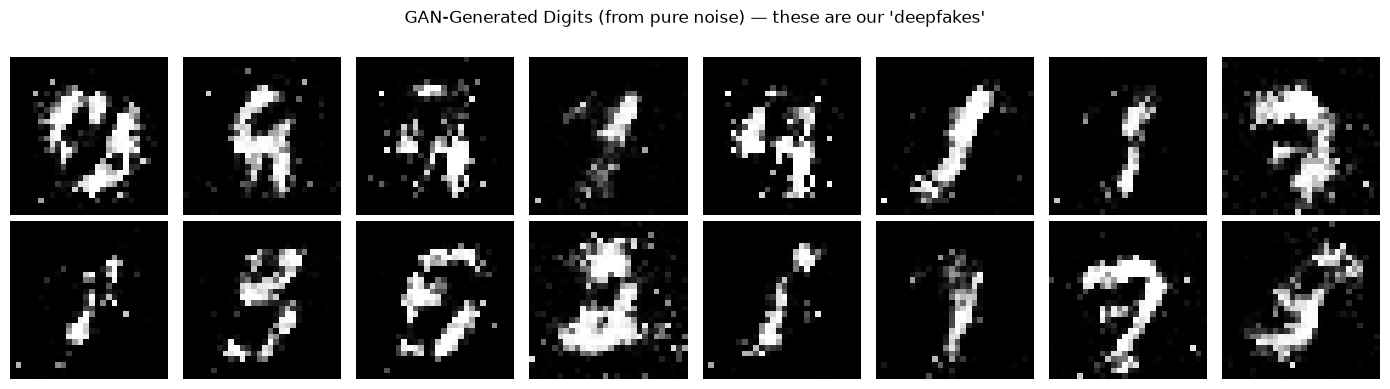

In [4]:
# Step 1 — train a small GAN so we have "fakes" to detect.
# Generator G maps random noise to a 28x28 image; discriminator D learns real-vs-fake;
# training alternates the two until G's samples start to look like digits.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

transform = T.Compose([T.ToTensor(), T.Normalize([0.5],[0.5])])
dataset   = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=transform)
loader    = torch.utils.data.DataLoader(dataset, batch_size=BATCH, shuffle=True)

# ── Generator: noise → image ───────────────────────────────────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
# ── Discriminator: image → real/fake ─────────────────────────────────────
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))
bce   = nn.BCELoss()

# WHAT/WHY: hold ONE batch of noise vectors fixed for the whole run. Decoding the SAME z
# after every epoch means any change we see later is the generator learning, not new noise.
fixed_z = torch.randn(6, LATENT_DIM)
epoch_samples = []          # one snapshot of those 6 digits per epoch = the animation frames

d_losses, g_losses = [], []
for epoch in range(10):
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        # ── Train Discriminator ─────────────────────────────────────────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()
        loss_D = bce(D(real_flat), torch.ones(bs,1)) + bce(D(fake), torch.zeros(bs,1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # ── Train Generator ─────────────────────────────────────────────
        z      = torch.randn(bs, LATENT_DIM)
        fake   = G(z)
        loss_G = bce(D(fake), torch.ones(bs,1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    d_losses.append(loss_D.item()); g_losses.append(loss_G.item())
    # Snapshot the fixed noise vectors at the end of this epoch (one cheap forward pass).
    with torch.no_grad():
        epoch_samples.append(G(fixed_z).view(-1, 28, 28).numpy().copy())
    print(f"Epoch {epoch+1}/10 — D loss: {d_losses[-1]:.3f}  G loss: {g_losses[-1]:.3f}")

# ── Show generated images ──────────────────────────────────────────────────
G.eval()
with torch.no_grad():
    samples = G(torch.randn(16, LATENT_DIM)).view(16, 28, 28).numpy()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray'); ax.axis('off')
plt.suptitle("GAN-Generated Digits (from pure noise) — these are our 'deepfakes'")
plt.tight_layout(); plt.show()

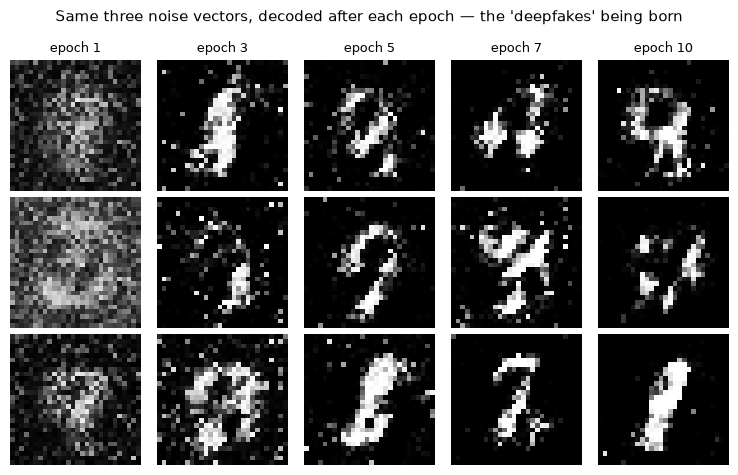

 epoch   D loss   G loss  mean |pixel|   (0 = flat grey, higher = more ink)
     1    0.631    2.606         0.596
     2    0.591    2.086         0.821
     3    0.592    1.700         0.875
     4    0.451    1.882         0.915
     5    0.489    2.154         0.909
     6    0.550    1.827         0.919
     7    0.500    3.181         0.931
     8    0.680    1.847         0.925
     9    0.592    2.047         0.929
    10    0.702    1.544         0.928


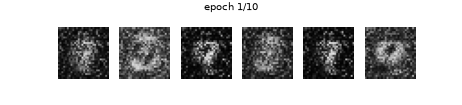


Animation above: 10 frames, one per training epoch, same six noise vectors.


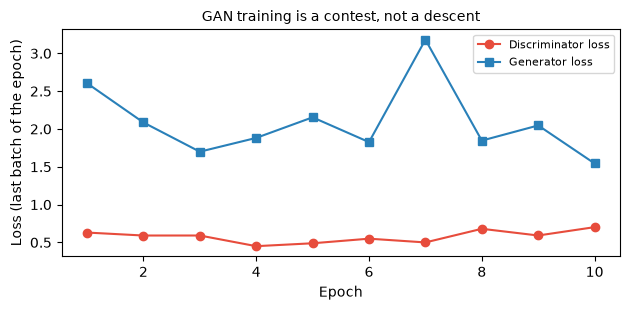

D loss range 0.45-0.70; G loss range 1.54-3.18. Neither curve has to fall for training to be working.


In [5]:
# WHAT/WHY: the grid above shows only the FINISHED generator. The claim this lesson rests on is
# that these fakes were NOT there at the start - the generator walked from noise to digit-like
# images in ten epochs, and a detector has to keep up with that walk. Below we hold the input noise
# FIXED and decode it as the generator trains: first a static storyboard (three of those vectors at
# five epochs - always renders), then the full animation (six vectors, all ten epochs) built with
# the diploma's shared step-visualisation helper from Course 09.
import sys
from pathlib import Path

# Walk up the folder tree to find the repo root, where Course 09 keeps the shared helper.
for _d in [Path.cwd(), *Path.cwd().parents]:
    if (_d / 'Course 09' / 'course09_step_viz.py').exists():
        sys.path.insert(0, str(_d / 'Course 09'))
        break
try:
    import course09_step_viz as cs9viz
except ImportError:
    cs9viz = None
    print('course09_step_viz.py not found - showing the static storyboard only.')

# Every panel below uses the SAME grey scale (-1..1, the generator's Tanh range) so that
# brightness changes across epochs are real changes, not autoscaling.
SCALE = dict(cmap='gray', vmin=-1, vmax=1)

# ── 1. STATIC STORYBOARD: rows = three fixed noise vectors, columns = epochs ───────────────
show_epochs = [0, 2, 4, 6, 9]                      # display epochs 1, 3, 5, 7, 10
fig, axes = plt.subplots(3, len(show_epochs), figsize=(1.5 * len(show_epochs), 4.8))
for col, e in enumerate(show_epochs):
    for row in range(3):
        ax = axes[row, col]
        ax.imshow(epoch_samples[e][row], **SCALE); ax.axis('off')
        if row == 0:
            ax.set_title(f'epoch {e + 1}', fontsize=9)
fig.suptitle("Same three noise vectors, decoded after each epoch — the 'deepfakes' being born",
             fontsize=11)
plt.tight_layout(); plt.show()

# ── 2. STEP TABLE: the numbers behind the storyboard ───────────────────────────────────────
print(f"{'epoch':>6}{'D loss':>9}{'G loss':>9}{'mean |pixel|':>14}   (0 = flat grey, higher = more ink)")
for e in range(len(epoch_samples)):
    print(f"{e + 1:6d}{d_losses[e]:9.3f}{g_losses[e]:9.3f}{np.abs(epoch_samples[e]).mean():14.3f}")

# ── 3. ANIMATION: the same frames as a GIF (the Course 09 visual idiom) ────────────────────
def fig_to_rgb(f):
    """Render a matplotlib figure into an RGB array — one frame of the animation."""
    f.canvas.draw()
    try:
        return np.asarray(f.canvas.buffer_rgba())[..., :3].copy()
    except AttributeError:                     # very old backends have no rgba buffer
        import io as _io
        from PIL import Image as _Image
        buf = _io.BytesIO(); f.savefig(buf, format='png', dpi=70); buf.seek(0)
        return np.asarray(_Image.open(buf).convert('RGB'))

frames = []
for e in range(len(epoch_samples)):            # 10 frames, one per epoch - cheap and capped
    f, axs = plt.subplots(1, 6, figsize=(6.6, 1.5), dpi=70)
    for i, ax in enumerate(axs):
        ax.imshow(epoch_samples[e][i], **SCALE); ax.axis('off')
    f.suptitle(f'epoch {e + 1}/10', fontsize=10)
    frames.append(fig_to_rgb(f))
    plt.close(f)                                # close so only the GIF is displayed, not 10 figures

if cs9viz is not None:
    cs9viz.display_gif(frames, duration_ms=550)
    print(f'\nAnimation above: {len(frames)} frames, one per training epoch, same six noise vectors.')

# ── 4. The training curves we recorded but never looked at ────────────────────────────────
fig, ax = plt.subplots(figsize=(6.4, 3.2))
ep = np.arange(1, len(d_losses) + 1)
ax.plot(ep, d_losses, 'o-', color='#e74c3c', label='Discriminator loss')
ax.plot(ep, g_losses, 's-', color='#2980b9', label='Generator loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (last batch of the epoch)')
ax.set_title('GAN training is a contest, not a descent', fontsize=10)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"D loss range {min(d_losses):.2f}-{max(d_losses):.2f}; "
      f"G loss range {min(g_losses):.2f}-{max(g_losses):.2f}. "
      "Neither curve has to fall for training to be working.")


### 🔎 Read the storyboard, the animation and the loss curves

**Both pictures hold the input noise fixed, so every change you see is the generator learning.**
The storyboard is *three* of those fixed noise vectors (one per row), decoded at five of the ten
epochs; the animation under it plays *six* vectors across all ten epochs, one frame per epoch. At **epoch 1**
there is nothing there — grey static, no black background, no strokes. By **epoch 3** a black
background and bright strokes have appeared. From **epoch 5** on, the shapes are stroke-like and
some are readable as digits (the bottom row becomes a recognisable 7, then a 1).

**Look at the last column honestly — it is not a clean set of digits.** Several samples are still
blobs, and every panel carries speckle. That visible imperfection is not a failed demo: it is
exactly the artifact the CNN detector exploits in the next cells, and it is why the detection
accuracy you are about to read is as high as it is. A generator trained ten times longer, with
convolutions instead of linear layers, leaves far less to find.

**The loss curves say something students almost always get wrong.** Neither loss falls steadily:
the discriminator's barely moves at all, and the generator's jumps *up* to its worst value of the
whole run at epoch 7 — yet the storyboard shows the samples improving across exactly those epochs. A GAN is a contest between two networks, so its losses measure who is
currently winning, not how good the images are. **You cannot read GAN progress off the loss; you
have to look at the samples.** That is what this figure is for.


## Part 3: Step 2 — Train the Detector and Measure Performance

We now build a labeled dataset: **real** MNIST digits (label 0) mixed with **fake** digits sampled
from the trained generator (label 1). We train the `DeepfakeDetector` CNN on one half and evaluate
on a held-out half — giving us an actual detection accuracy, not just an architecture diagram.

Epoch 1/2 — last batch loss: 0.5082


Epoch 2/2 — last batch loss: 0.2045

Detection accuracy on held-out set: 98.4%
  Real images correctly kept  : 98.5%
  Fake images correctly caught: 98.4%


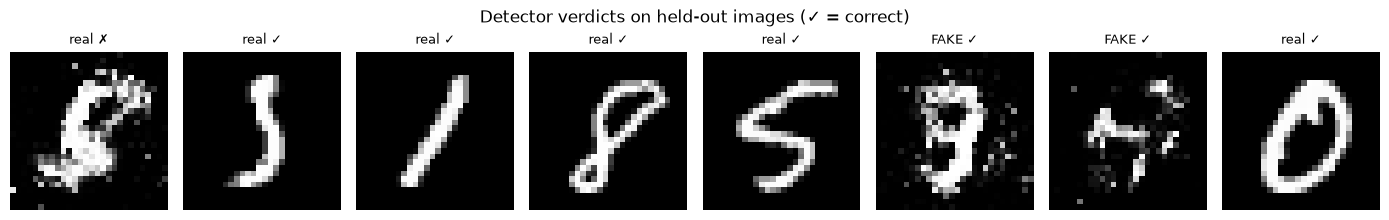

In [6]:
# Step 2 — train the CNN detector on real-vs-fake images and evaluate it.
# We deliberately hold out a test set so the reported accuracy is a real measurement.
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(0)
N_PER_CLASS = 3000  # 3000 real + 3000 fake images

# ── Build the dataset ──────────────────────────────────────────────────────
# Real digits: take MNIST images (already normalized to [-1,1], same range as G's Tanh output)
real_imgs = torch.stack([dataset[i][0] for i in range(N_PER_CLASS)])          # (N,1,28,28)
# Fake digits: sample the trained generator, reshape flat 784 -> image grid
with torch.no_grad():
    fake_imgs = G(torch.randn(N_PER_CLASS, LATENT_DIM)).view(-1, 1, 28, 28)
# Labels: real = 0, fake = 1
images = torch.cat([real_imgs, fake_imgs])
labels = torch.cat([torch.zeros(N_PER_CLASS, dtype=torch.long),
                    torch.ones(N_PER_CLASS, dtype=torch.long)])

# ── Split into train / test halves (shuffled) ─────────────────────────────
perm = torch.randperm(len(images))
images, labels = images[perm], labels[perm]
split = len(images) // 2
train_ds = TensorDataset(images[:split], labels[:split])
test_X, test_y = images[split:], labels[split:]
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

# ── Train the detector for 2 epochs ───────────────────────────────────────
detector = DeepfakeDetector()
opt  = optim.Adam(detector.parameters(), lr=1e-3)
lossf = nn.CrossEntropyLoss()
for epoch in range(2):
    detector.train()
    for xb, yb in train_loader:
        opt.zero_grad()
        loss = lossf(detector(xb), yb)
        loss.backward(); opt.step()
    print(f"Epoch {epoch+1}/2 — last batch loss: {loss.item():.4f}")

# ── Evaluate on the held-out half ─────────────────────────────────────────
detector.eval()
with torch.no_grad():
    pred = detector(test_X).argmax(1)
acc = (pred == test_y).float().mean().item()
# Per-class breakdown: how often reals and fakes are each caught correctly
real_acc = (pred[test_y == 0] == 0).float().mean().item()
fake_acc = (pred[test_y == 1] == 1).float().mean().item()
print(f"\nDetection accuracy on held-out set: {acc:.1%}")
print(f"  Real images correctly kept  : {real_acc:.1%}")
print(f"  Fake images correctly caught: {fake_acc:.1%}")

# ── Show a few test images with the detector's verdicts ───────────────────
fig, axes = plt.subplots(1, 8, figsize=(14, 2.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(test_X[i, 0].numpy(), cmap='gray'); ax.axis('off')
    verdict = 'FAKE' if pred[i] == 1 else 'real'
    correct = '✓' if pred[i] == test_y[i] else '✗'
    ax.set_title(f"{verdict} {correct}", fontsize=9)
plt.suptitle("Detector verdicts on held-out images (✓ = correct)")
plt.tight_layout(); plt.show()

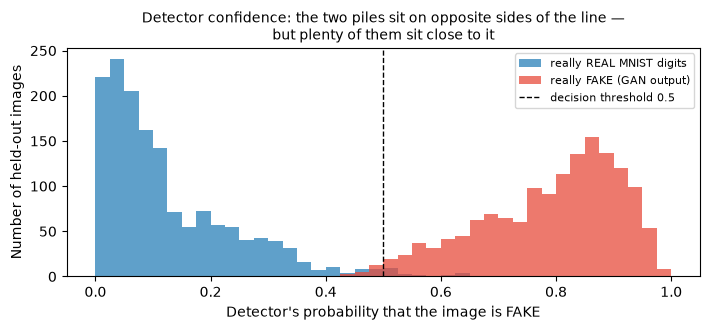

median P(fake) — real images 0.088 | fake images 0.817
images landing in the undecided band 0.2-0.8: 1009 of 3000 (33.6%)
Read that second number against the 98.4% accuracy: the detector is almost always on the
RIGHT side of the line, yet a third of its calls are made with real doubt. Separation is
not certainty - and a generator only slightly better than ours would push the red pile
left across the line without ever having to fool a human.


In [7]:
# WHAT/WHY: the accuracy printed above is a number. This is the picture behind it. For every held-out
# image we plot the detector's own probability that the image is FAKE, split by what the image
# actually is. The distance between the two piles is the artifact the CNN found - and closing
# that distance is exactly what a better generator does to a detector.
import torch.nn.functional as F

with torch.no_grad():
    p_fake = F.softmax(detector(test_X), dim=1)[:, 1].numpy()   # P(fake) for each test image
is_fake = (test_y.numpy() == 1)

fig, ax = plt.subplots(figsize=(7.2, 3.4))
bins = np.linspace(0, 1, 41)
ax.hist(p_fake[~is_fake], bins=bins, color='#2980b9', alpha=0.75, label='really REAL MNIST digits')
ax.hist(p_fake[is_fake], bins=bins, color='#e74c3c', alpha=0.75, label="really FAKE (GAN output)")
ax.axvline(0.5, color='black', ls='--', lw=1, label='decision threshold 0.5')
ax.set_xlabel("Detector's probability that the image is FAKE")
ax.set_ylabel('Number of held-out images')
ax.set_title('Detector confidence: the two piles sit on opposite sides of the line —\nbut plenty of them sit close to it', fontsize=10)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# ── Quantify the picture instead of trusting the eye ──────────────────────────────────────
undecided = int(((p_fake > 0.2) & (p_fake < 0.8)).sum())
print(f"median P(fake) — real images {np.median(p_fake[~is_fake]):.3f} | "
      f"fake images {np.median(p_fake[is_fake]):.3f}")
print(f"images landing in the undecided band 0.2-0.8: {undecided} of {len(p_fake)} "
      f"({undecided / len(p_fake):.1%})")
print(f"Read that second number against the {acc:.1%} accuracy: the detector is almost always on the")
print("RIGHT side of the line, yet a third of its calls are made with real doubt. Separation is")
print("not certainty - and a generator only slightly better than ours would push the red pile")
print("left across the line without ever having to fool a human.")


### 🔎 Read the confidence histogram

The blue pile (real MNIST) sits left of the dashed threshold and the red pile (GAN output) sits
right of it, with almost nothing crossing — that crossing-free gap *is* the 98.4% accuracy printed
above, drawn instead of asserted.

But the piles are not jammed against 0 and 1. A third of the held-out images land in the undecided
0.2–0.8 band, and the red pile's left shoulder reaches down toward the line. The detector is
**separating, not certain**, and the margin it survives on is only as wide as our generator's
artifacts. Every improvement to the generator shifts that red pile left; the day it crosses the
dashed line, this detector reports "real" with the same confidence it shows here.

That is the arms race in one picture — and the reason the next section's caveats matter more than
the accuracy number.


### Reading the Result — and Its Limits

The accuracy above is high because our fully-connected GAN leaves **obvious artifacts** (blur,
noise texture) that the CNN spots easily. Two honest caveats that carry over to real deepfake work:

1. **Detectors overfit their generator.** This detector learned *this* GAN's artifacts; a fake from
   a different, better generator could slip through. Real benchmarks (e.g., Meta's Deepfake
   Detection Challenge) test on *unseen* generators — accuracy drops sharply.
2. **It's an arms race.** Better generators erase the artifacts detectors rely on, which is why
   provenance standards (watermarking, C2PA content credentials) complement detection.

## 💬 Discuss

1. Our detector reports **98.4% accuracy, catching 98.4% of the fakes** — a better score than any entry in Meta's Deepfake Detection Challenge ever managed on unseen generators. Why is our number the *less* trustworthy one, and what single experiment would make ours honest?
2. In the Arup case the fake was live video inside a meeting. Where in that pipeline would a detector like ours sit — and would it have helped? If not, name the control that would have, and say why it is unglamorous.
3. You can fund detection *or* provenance for a Saudi bank, not both. Which do you choose, and what specifically does the other's absence cost you in the first year?


## ⚠️ Where this breaks

The section above named the two failures qualitatively. Here is what they cost, measured, plus the two the notebook has not mentioned.

**Put a number on "detectors overfit their generator."** Meta's Deepfake Detection Challenge is the calibration: the winning entry scored **82.56% average precision on the public set and 65.18% on the unseen black-box set** — and the model that won the black-box round had ranked only fourth on the public leaderboard. Our 98.4% is measured on the *same* generator we trained against, so it is not a detection accuracy at all; it is an artefact-memorisation score. An honest evaluation holds out the **generator**, not just the images.

**Platform processing destroys the evidence.** Compression, resizing and re-encoding — everything that happens to an upload — attenuate exactly the low-level artefacts these classifiers rely on. A detector validated on pristine files degrades sharply on real social-media traffic, and nothing in a held-out split will warn you.

**Detection has a structural lag.** A detector can only be trained after a generator exists and its outputs have been collected. Every new generator arrives against a blind detector, and the gap is measured in months — which is why detection can never be the only control.

**The control that would have stopped the Arup transfers was procedural.** Provenance at capture (C2PA content credentials) and generation-time watermarking (Kirchenbauer et al., 2023, arXiv 2301.10226) attach a signal rather than hunting for one — necessary, and still insufficient alone, since unmarked media is merely unmarked. What actually defends a payment process is call-back verification on a separately-known number and dual authorisation above a threshold. A classifier was never going to be in that meeting.


## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the detector you build above, exactly as it is taught. This box says where that detector sits on the 2026 map.*

Practitioners no longer treat a trained classifier as the primary defence, for two reasons. **Evaluation moved to holding out the generator, not the images:** DF40 (Yan *et al.*, 2024, arXiv 2406.13495) assembles **40 distinct forgery techniques** in one benchmark precisely because a detector trained and tested against a single generation method — which is what our 98.4% measures — does not predict real-world performance. **And weight shifted from detection to provenance at creation time:** SynthID-Image (Gowal *et al.*, 2025, arXiv 2510.09263) is a watermarking system for AI-generated imagery deployed across Google's services at internet scale, and EU AI Act Article 50 turns machine-readable marking of synthetic media into a legal obligation rather than a courtesy.

Neither change retires this lesson. A watermark only ever tells you about content somebody chose to mark, so a classifier remains the only instrument you can point at unmarked media — and building one from a generator you trained yourself is how you learn what an artefact *is*, and why a better generator erases it. What the 2026 literature adds is the evaluation discipline that "Where this breaks" already names: hold out the **generator**. That is also what the official plan examines here — the mechanism, and its honest limits.

**Read:** Yan *et al.* (2024), <https://arxiv.org/abs/2406.13495> · Gowal *et al.* (2025), <https://arxiv.org/abs/2510.09263> (both added to the references below).


## 📚 References & Further Reading

**Foundational Papers:**
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(the technology behind deepfakes)*
- Rössler et al. (2019) — [FaceForensics++: Learning to Detect Manipulated Facial Images](https://arxiv.org/abs/1901.08971) *(the standard deepfake-detection benchmark)*

**Recent:**
- Mirsky & Lee (2021) — [The Creation and Detection of Deepfakes: A Survey](https://arxiv.org/abs/2004.11138) *(ACM Computing Surveys)*
- Karras et al. (2020) — [StyleGAN2](https://arxiv.org/abs/1912.04958) *(the face generator behind "this person does not exist")*
- Yan et al. (2024) — [DF40: Toward Next-Generation Deepfake Detection](https://arxiv.org/abs/2406.13495) *(a benchmark of 40 distinct forgery techniques, built because training and testing on one generation method — exactly what this notebook does — does not predict real-world performance)*
- Gowal et al. (2025) — [SynthID-Image: Image watermarking at internet scale](https://arxiv.org/abs/2510.09263) *(the provenance side of the arms race: watermarking applied at generation time and deployed across Google's services)*
- Chandra et al. (2025) — [Deepfake-Eval-2024: A Multi-Modal In-the-Wild Benchmark of Deepfakes Circulated in 2024](https://arxiv.org/abs/2503.02857) *(deepfakes actually circulating on social media in 2024 — 45 hours of video, 56.5 hours of audio and 1,975 images across 52 languages; open-source state-of-the-art detectors lose roughly half their AUC on it relative to earlier academic datasets: -50% video, -48% audio, -45% image)*
- Ren et al. (2026) — [How well are open sourced AI-generated image detection models out-of-the-box: A comprehensive benchmark study](https://arxiv.org/abs/2602.07814) *(zero-shot evaluation of 16 detection methods / 23 pretrained variants across 12 datasets, 2.6 million images and 291 generators; the finding is that "no universal winner exists" — average accuracy across detectors ranges from 75.0% down to 37.5%)*

**State-of-the-Art:** detectors still generalize poorly to unseen generators — detection is an arms race, which is why provenance standards (C2PA content credentials) are rising alongside classifiers.